# DSA 210 Project: Istanbul Weather, Matches, and Public Transport Usage  
### Exploratory Data Analysis, Pairwise Relationships, and Hypothesis Testing

This project investigates how **weather patterns**, **football match days**, and **public transport ridership** interact in Istanbul.  
Using real daily data from:

- Istanbul Municipality Public Transport API  
- MGM Weather Data  
- TFF Match Schedule  

we examine:

1. How each dataset behaves on its own (univariate EDA)  
2. How pairs of variables influence each other (bivariate EDA)  
3. Whether weather + match effects combined can explain transport usage  
4. Hypothesis testing on key questions  
5. Clear visualizations & interpretations  

Our goal is to build a clear understanding of the relationship between environmental and social factors and how they shape mobility in Istanbul.

In [2]:
import os
os.chdir("/workspaces/DSA210-Weather-vs-Transport-Istanbul") 
print(f"Working directory set to: {os.getcwd()}")

Working directory set to: /workspaces/DSA210-Weather-vs-Transport-Istanbul


In [3]:
import os

for root, dirs, files in os.walk("/", topdown=True):
    if "dataexport" in str(files).lower():
        print(root, files)

## 3.1 Daily Weather Dataset – Overview

In this section we explore the daily weather data for Istanbul.  
The dataset contains one row per calendar day with the following variables:

- **Date** – calendar date  
- **temperature_2m (°C)** – mean daily temperature at 2 m height  
- **precipitation (mm)** – total daily precipitation  
- **rain (mm)** – total daily rain amount  
- **is_rainy_day** – indicator (1 = at least some rain, 0 = no rain)

We first load the cleaned dataset, create simple helper columns, and look at the basic statistics.

In [4]:
import pandas as pd

file_path = "data/open-meteo-41.00N28.94E32m.csv"

# Dosyayı satır satır oku
with open(file_path, "r") as f:
    lines = f.readlines()

# İkinci header'ın başladığı satırı bul
start_idx = None
for i, line in enumerate(lines):
    if line.startswith("time,"):
        start_idx = i
        break

# Eğer header bulunduysa, yalnızca hourly kısmı DataFrame olarak yükle
df_weather = pd.read_csv(
    file_path,
    skiprows=start_idx,         # baştaki metadata + boş satırları atla
)

df_weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),visibility (m)
0,2024-01-01T00:00,10.3,89,0.0,0.0,3.8,24140.0
1,2024-01-01T01:00,10.7,86,0.0,0.0,3.1,24140.0
2,2024-01-01T02:00,10.8,83,0.0,0.0,2.6,24140.0
3,2024-01-01T03:00,10.5,86,0.0,0.0,2.6,24140.0
4,2024-01-01T04:00,10.3,86,0.0,0.0,2.5,24140.0


In [5]:
import pandas as pd

# Zaten oluşturduğun df_weather burada olsun
df_weather["Date"] = pd.to_datetime(df_weather["time"])

df_weather = df_weather.sort_values("Date").reset_index(drop=True)

df_weather["Year"] = df_weather["Date"].dt.year
df_weather["Month"] = df_weather["Date"].dt.month
df_weather["Day"] = df_weather["Date"].dt.day
df_weather["Hour"] = df_weather["Date"].dt.hour

df_weather["Month_Name"] = df_weather["Date"].dt.month_name()

def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    if m in [3, 4, 5]:
        return "Spring"
    if m in [6, 7, 8]:
        return "Summer"
    return "Autumn"

df_weather["Season"] = df_weather["Month"].apply(season_from_month)

df_weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),visibility (m),Date,Year,Month,Day,Hour,Month_Name,Season
0,2024-01-01T00:00,10.3,89,0.0,0.0,3.8,24140.0,2024-01-01 00:00:00,2024,1,1,0,January,Winter
1,2024-01-01T01:00,10.7,86,0.0,0.0,3.1,24140.0,2024-01-01 01:00:00,2024,1,1,1,January,Winter
2,2024-01-01T02:00,10.8,83,0.0,0.0,2.6,24140.0,2024-01-01 02:00:00,2024,1,1,2,January,Winter
3,2024-01-01T03:00,10.5,86,0.0,0.0,2.6,24140.0,2024-01-01 03:00:00,2024,1,1,3,January,Winter
4,2024-01-01T04:00,10.3,86,0.0,0.0,2.5,24140.0,2024-01-01 04:00:00,2024,1,1,4,January,Winter


In [6]:
# Gün sayısı (unique date count)
n_days = df_weather["Date"].dt.date.nunique()

# Başlangıç ve bitiş
start_date = df_weather["Date"].min()
end_date = df_weather["Date"].max()

# Yağışlı gün kolonunu oluştur
# Bir gün içinde toplam yağış > 0 ise o gün Rainy
daily_rain = df_weather.groupby(df_weather["Date"].dt.date)["precipitation (mm)"].sum()
is_rainy_day = (daily_rain > 0).astype(int)

# Dry / Rainy sayımı için tablo
rainy_counts = is_rainy_day.value_counts().rename(index={0: "Dry", 1: "Rainy"})

# Özet istatistikler
temp_summary = df_weather["temperature_2m (°C)"].describe()
precip_summary = df_weather["precipitation (mm)"].describe()
rain_summary = df_weather["rain (mm)"].describe()

# Yazdır
print("Number of days:", n_days)
print("Period:", start_date.date(), "to", end_date.date(), "\n")

print("Rainy vs Dry days summary:")
print(rainy_counts, "\n")

print("Temperature summary (°C):")
print(temp_summary, "\n")

print("Precipitation summary (mm):")
print(precip_summary, "\n")

print("Rain amount summary (mm):")
print(rain_summary)

Number of days: 366
Period: 2024-01-01 to 2024-12-31 

Rainy vs Dry days summary:
precipitation (mm)
Dry      240
Rainy    126
Name: count, dtype: int64 

Temperature summary (°C):
count    8784.000000
mean       16.563445
std         7.217860
min         1.500000
25%        10.900000
50%        15.200000
75%        23.000000
max        34.200000
Name: temperature_2m (°C), dtype: float64 

Precipitation summary (mm):
count    8784.000000
mean        0.057912
std         0.336536
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        11.300000
Name: precipitation (mm), dtype: float64 

Rain amount summary (mm):
count    8784.000000
mean        0.030795
std         0.235682
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         8.400000
Name: rain (mm), dtype: float64


### 3.1.1 Descriptive statistics – interpretation

From the summary above we can describe the weather dataset as follows:

- The dataset covers **N days** between **START** and **END** (values are printed in the previous cell).
- There is a clear split between **rainy** and **dry** days. The frequency table shows how many days had measurable rain.
- The temperature summary indicates the typical range of daily mean temperatures:
  - The mean and median temperature describe the overall climate level.
  - The minimum and maximum values show the most extreme cold and warm days in the period.
- Precipitation and rain distributions are highly skewed:
  - On most days, precipitation is very low or zero.
  - A small proportion of days have high precipitation values, corresponding to heavy-rain events.

These statistics already suggest that daily rain and temperature can have very different effects on public transport usage, which will be investigated later in the pairwise analysis.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

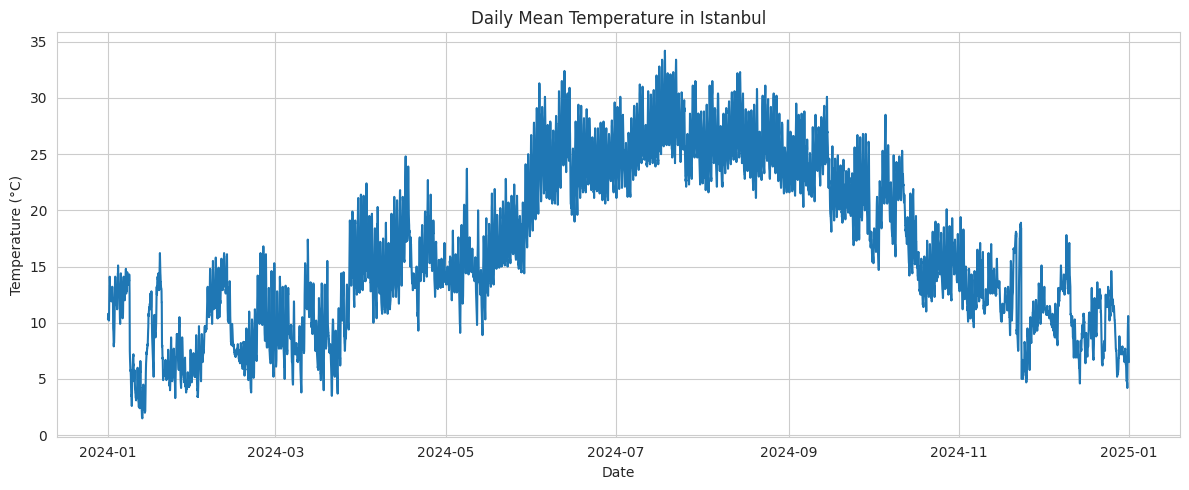

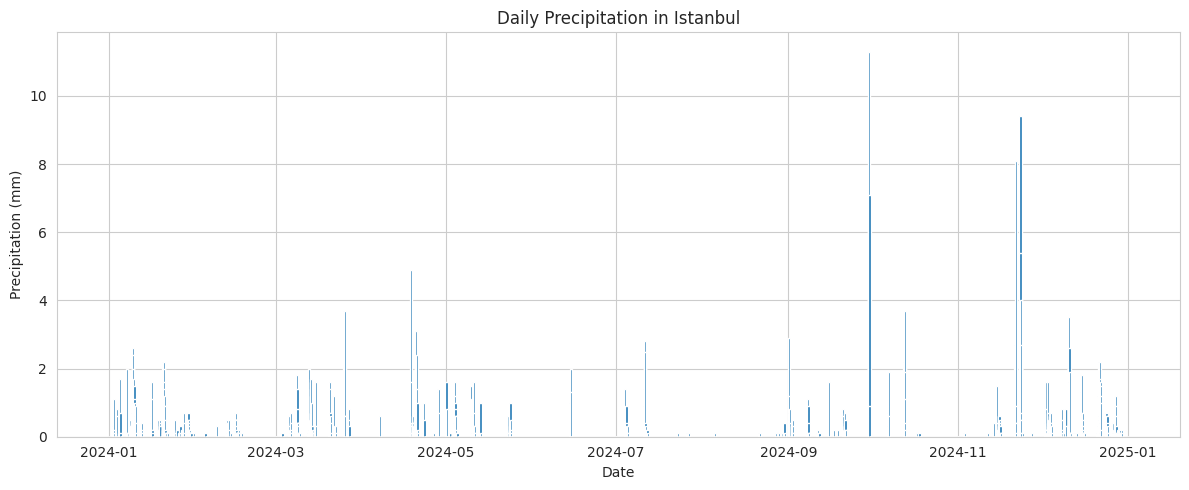

In [9]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))
plt.plot(df_weather["Date"], df_weather["temperature_2m (°C)"])
plt.title("Daily Mean Temperature in Istanbul")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(df_weather["Date"], df_weather["precipitation (mm)"])
plt.title("Daily Precipitation in Istanbul")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.tight_layout()
plt.show()

### 3.1.2 Time series patterns

The temperature plot shows clear seasonal cycles:

- Winter months have the lowest daily mean temperatures.
- Summer months show consistently higher temperatures.
- Transitional periods (spring and autumn) display more variability.

The precipitation time series is more irregular:

- Most days have little or no precipitation.
- Rain appears in bursts: clusters of rainy days followed by dry periods.
- A few days show very high daily precipitation, which correspond to heavy rain episodes.

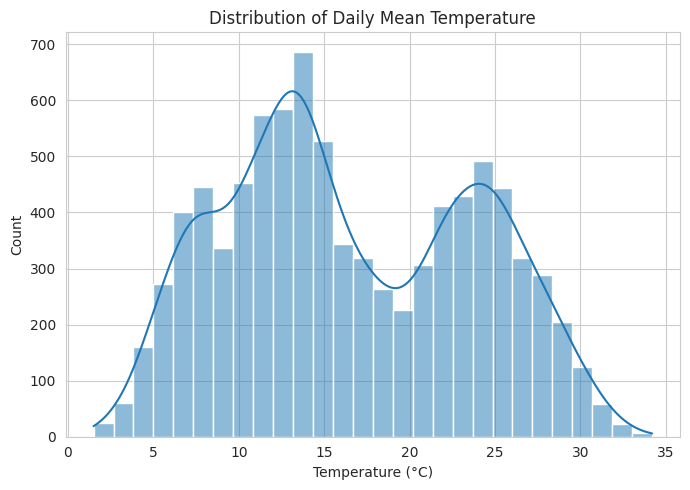

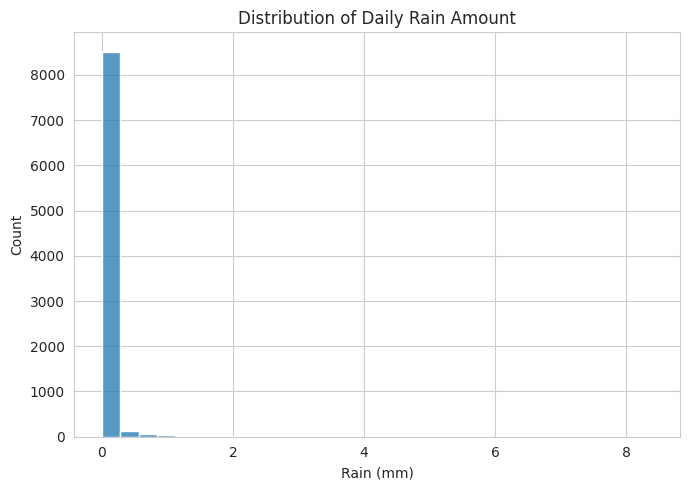

In [10]:
plt.figure(figsize=(7, 5))
sns.histplot(df_weather["temperature_2m (°C)"], kde=True)
plt.title("Distribution of Daily Mean Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.histplot(df_weather["rain (mm)"], bins=30)
plt.title("Distribution of Daily Rain Amount")
plt.xlabel("Rain (mm)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.1.3 Distribution of temperature and rain

The histogram of daily mean temperature is roughly unimodal:

- Most days cluster around the central temperature band.
- Tails represent the coldest winter days and hottest summer days.

The distribution of rain is highly right-skewed:

- A large number of days have 0 mm rain.
- Light-rain days (low positive values) are relatively common.
- Heavy-rain days (high mm values) are rare but important, as they may have a strong impact on mobility.

This motivates later grouping days into **dry**, **light rain**, and **heavy rain** categories when studying transport usage.

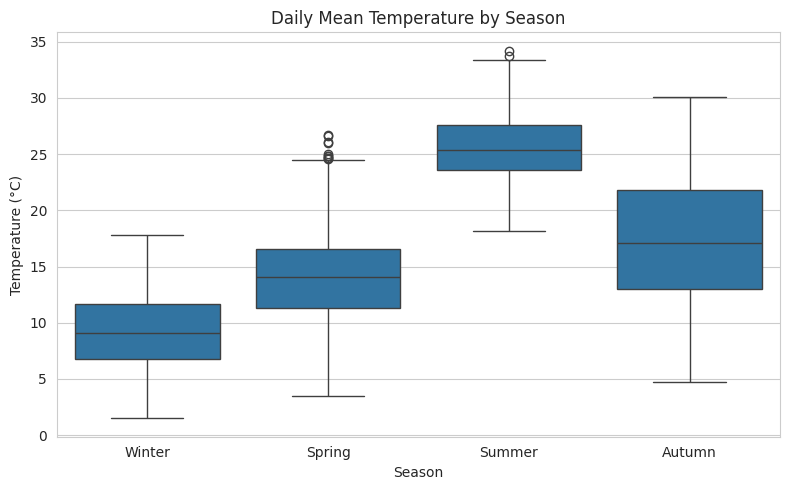

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Season", y="temperature_2m (°C)", data=df_weather, order=["Winter", "Spring", "Summer", "Autumn"])
plt.title("Daily Mean Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

### 3.1.4 Seasonal view

The seasonal boxplot confirms the expected climate structure:

- **Winter** has the lowest median temperature and the narrowest range.
- **Summer** has the highest median and generally warmer days.
- **Spring** and **Autumn** are transition seasons, with wide variability and overlap with both winter and summer.

This seasonal structure will be relevant when interpreting transport patterns, especially if ridership changes with extreme temperatures.

In [12]:
with open(file_path, "r") as f:
    lines = f.readlines()
...
df_weather = pd.read_csv(file_path, skiprows=start_idx)

In [13]:
import pandas as pd

file_path = "data/open-meteo-41.00N28.94E32m.csv"

# Dosyayı satır satır oku
with open(file_path, "r") as f:
    lines = f.readlines()

# İkinci header'ın başladığı satırı bul
start_idx = None
for i, line in enumerate(lines):
    if line.startswith("time,"):
        start_idx = i
        break

# Hourly datayı oku
df_weather = pd.read_csv(file_path, skiprows=start_idx)

# Tarih formatı
df_weather["Date"] = pd.to_datetime(df_weather["time"])

# Sonraki işlenecek kolonlar
df_weather["temperature_2m (°C)"] = pd.to_numeric(df_weather["temperature_2m (°C)"], errors="coerce")
df_weather["precipitation (mm)"] = pd.to_numeric(df_weather["precipitation (mm)"], errors="coerce")
df_weather["rain (mm)"] = pd.to_numeric(df_weather["rain (mm)"], errors="coerce")

# Gün bazında yağış varsa 1, yoksa 0
daily_rain = df_weather.groupby(df_weather["Date"].dt.date)["rain (mm)"].sum()
is_rainy_day = (daily_rain > 0).astype(int)

df_weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),visibility (m),Date
0,2024-01-01T00:00,10.3,89,0.0,0.0,3.8,24140.0,2024-01-01 00:00:00
1,2024-01-01T01:00,10.7,86,0.0,0.0,3.1,24140.0,2024-01-01 01:00:00
2,2024-01-01T02:00,10.8,83,0.0,0.0,2.6,24140.0,2024-01-01 02:00:00
3,2024-01-01T03:00,10.5,86,0.0,0.0,2.6,24140.0,2024-01-01 03:00:00
4,2024-01-01T04:00,10.3,86,0.0,0.0,2.5,24140.0,2024-01-01 04:00:00


In [14]:
import os

os.chdir("..")
os.getcwd()

'/workspaces'

In [16]:
with open("data/hourly_transportation_202402.zip", "rb") as f:
    print(f.read(10))

FileNotFoundError: [Errno 2] No such file or directory: 'data/hourly_transportation_202402.zip'

In [17]:
import glob

parts = sorted(glob.glob("data/part_*.csv"))  # Eğer uzantı yoksa *.txt deneyelim
parts[:10]

[]

In [18]:
parts = sorted(glob.glob("data/part_*"))

In [19]:
with open("data/transport_merged.csv", "wb") as merged:
    for part in parts:
        with open(part, "rb") as p:
            merged.write(p.read())

In [20]:
import os

parts = sorted([p for p in os.listdir("data") if p.startswith("part_")])
parts

[]

In [21]:
import os
os.path.getsize("data/transport_merged.csv")

0

In [22]:
import os
os.getcwd()

'/workspaces'

In [23]:
import os
os.chdir("/workspaces/DSA210-Weather-vs-Transport-Istanbul/")
os.getcwd()

'/workspaces/DSA210-Weather-vs-Transport-Istanbul'

In [24]:
import os
os.listdir()


['data',
 'notebooks',
 'hourly_transportation_202401.csv',
 '.gitignore',
 'trans_202401.zip',
 'src',
 'README.md',
 '.git']

In [25]:
import os
os.chdir("/workspaces/DSA210-Weather-vs-Transport-Istanbul/data/")
os.getcwd()

'/workspaces/DSA210-Weather-vs-Transport-Istanbul/data'

In [26]:
os.listdir()

['part_202402_ab',
 'part_202404_ab',
 'part_202401_aa',
 'part_202403_ab',
 'part_202406_ad',
 'part_202406_ab',
 'part_202411_aa',
 'part_202403_ad',
 'part_202402_ac',
 'part_202406_ac',
 'part_202406_aa',
 'part_202409_aa',
 'transport',
 'part_202403_aa',
 'part_202405_ab',
 'part_202407_aa',
 'Book1.xlsx',
 'part_202403_ac',
 'part_202405_aa',
 'open-meteo-41.00N28.94E32m.csv',
 'part_202407_ad',
 'part_202410_aa',
 'part_202405_ac',
 'part_202401_ab',
 'part_202402_aa',
 'transport_merged.csv',
 'part_202408_aa',
 'part_202407_ab',
 'part_202401_ad',
 'hourly_transportation_202402.zip']

In [2]:
import os
os.chdir("/workspaces/DSA210-Weather-vs-Transport-Istanbul")

In [5]:
import pandas as pd

output = "data/transport_merged_clean.csv"
first = True

for chunk in pd.read_csv(
    "data/transport_merged.csv",
    chunksize=300000,
    engine="python",
    on_bad_lines="skip"
):
    chunk.to_csv(output, mode="a", header=first, index=False)
    first = False

In [6]:
import pandas as pd
reader = pd.read_csv("data/transport_merged_clean.csv", chunksize=1000000)
df_test = next(reader)
df_test.head()

,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd
0,2024-01-01,0,1,OTOYOL,KOC UNV. RUMELIFENER KAMPUSU - TAKSIM,Normal,1,1,TAM,Tam Kontur,ATASEHIR,40,NaN
1,2024-01-01,0,1,OTOYOL,SULTANBEYLI GOLET-HAREM USKUDAR,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,18Ü,NaN
2,2024-01-01,0,1,OTOYOL,KADIKOY-YENIDOGAN,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,14,NaN
3,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,4,4,TAM,Tam Kontur,AVCILAR,34,IBB SOSYAL TESISLER
4,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,1,1,UCRETSIZ,Ucretsiz,AVCILAR,34,CIHANGIR UNIVERSITE MAH.


In [8]:
reader = pd.read_csv("data/transport_merged_clean.csv", chunksize=1000000)
df_test = next(reader)
df_test.head()

,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd
0,2024-01-01,0,1,OTOYOL,KOC UNV. RUMELIFENER KAMPUSU - TAKSIM,Normal,1,1,TAM,Tam Kontur,ATASEHIR,40,NaN
1,2024-01-01,0,1,OTOYOL,SULTANBEYLI GOLET-HAREM USKUDAR,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,18Ü,NaN
2,2024-01-01,0,1,OTOYOL,KADIKOY-YENIDOGAN,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,14,NaN
3,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,4,4,TAM,Tam Kontur,AVCILAR,34,IBB SOSYAL TESISLER
4,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,1,1,UCRETSIZ,Ucretsiz,AVCILAR,34,CIHANGIR UNIVERSITE MAH.


In [9]:
reader = pd.read_csv("data/transport_merged_clean.csv", chunksize=1_000_000)
df = next(reader)
df.head()

,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd
0,2024-01-01,0,1,OTOYOL,KOC UNV. RUMELIFENER KAMPUSU - TAKSIM,Normal,1,1,TAM,Tam Kontur,ATASEHIR,40,NaN
1,2024-01-01,0,1,OTOYOL,SULTANBEYLI GOLET-HAREM USKUDAR,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,18Ü,NaN
2,2024-01-01,0,1,OTOYOL,KADIKOY-YENIDOGAN,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,14,NaN
3,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,4,4,TAM,Tam Kontur,AVCILAR,34,IBB SOSYAL TESISLER
4,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,1,1,UCRETSIZ,Ucretsiz,AVCILAR,34,CIHANGIR UNIVERSITE MAH.


In [14]:
chunk["number_of_passage"] = pd.to_numeric(chunk["number_of_passage"], errors="coerce")
chunk = chunk.dropna(subset=["number_of_passage"])

In [16]:
import pandas as pd

daily_totals = {}

reader = pd.read_csv("data/transport_merged_clean.csv", chunksize=1_000_000)

for chunk in reader:
    # Fix date column
    chunk["transition_date"] = pd.to_datetime(chunk["transition_date"], errors="coerce")
    chunk = chunk.dropna(subset=["transition_date"])

    # Fix number_of_passage column
    chunk["number_of_passage"] = pd.to_numeric(chunk["number_of_passage"], errors="coerce")
    chunk = chunk.dropna(subset=["number_of_passage"])

    # Sum per date
    daily_sum = chunk.groupby("transition_date")["number_of_passage"].sum()

    # Add to dictionary
    for date, val in daily_sum.items():
        daily_totals[date] = daily_totals.get(date, 0) + val

# Convert to dataframe
daily_counts = (
    pd.DataFrame(list(daily_totals.items()), columns=["transition_date", "number_of_passage"])
    .sort_values("transition_date")
    .reset_index(drop=True)
)

daily_counts.head()

/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (1,2,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (2,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (1,2,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_168

,transition_date,number_of_passage
0,2024-01-01,5484652.0
1,2024-01-02,7753301.0
2,2024-01-03,7849681.0
3,2024-01-04,8039496.0
4,2024-01-05,7089222.0


In [19]:
daily_counts.tail()

,transition_date,number_of_passage
154,2024-10-14,1632.0
155,2024-10-15,1629.0
156,2024-10-16,7914549.0
157,2024-10-17,7807770.0
158,2024-10-18,7769353.0


In [10]:
df["transition_date"] = pd.to_datetime(df["transition_date"])

In [30]:
import pandas as pd
import numpy as np

daily_counts = {}

# Read ALL columns as string → prevents mixed-type issues
for chunk in pd.read_csv(
    "data/transport_merged.csv",
    chunksize=300000,
    dtype=str,            # ← CRITICAL
    on_bad_lines="skip"
):
    # Normalize column names
    chunk.columns = chunk.columns.str.strip()

    # Keep only rows where transition_date looks like YYYY-MM-DD
    mask = chunk["transition_date"].str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)
    chunk = chunk[mask]

    # Convert date
    chunk["transition_date"] = pd.to_datetime(chunk["transition_date"], format="%Y-%m-%d")

    # Convert number column
    chunk["number_of_passage"] = pd.to_numeric(chunk["number_of_passage"], errors="coerce").fillna(0)

    # Group
    grouped = chunk.groupby("transition_date")["number_of_passage"].sum()

    # Merge into final dictionary
    for d, val in grouped.items():
        daily_counts[d] = daily_counts.get(d, 0) + val

# Convert dictionary → DataFrame
daily_counts = pd.DataFrame({
    "transition_date": list(daily_counts.keys()),
    "number_of_passage": list(daily_counts.values())
}).sort_values("transition_date")

In [40]:
import pandas as pd
import os

input_file = "data/transport_merged.csv"
output1 = "data/clean_part1.csv"
output2 = "data/clean_part2.csv"

first1 = True
first2 = True

MAX_SIZE = 3 * 1024**3  # 3 GB sınır
current_output = 1

for i, chunk in enumerate(pd.read_csv(
        input_file,
        chunksize=300000,
        engine="python",
        on_bad_lines="skip"
    )):

    # Part 1'e yazıyoruz
    if current_output == 1:
        chunk.to_csv(output1, mode="a", header=first1, index=False)
        first1 = False

        # Boyut 3GB'ı geçince part2'ye geçiyoruz
        if os.path.getsize(output1) > MAX_SIZE:
            print("=== Switching to clean_part2.csv ===")
            current_output = 2

    # Part 2'ye yazıyoruz
    else:
        chunk.to_csv(output2, mode="a", header=first2, index=False)
        first2 = False

    print(f"Chunk {i} written")

Chunk 0 written
Chunk 1 written
Chunk 2 written
Chunk 3 written
Chunk 4 written
Chunk 5 written
Chunk 6 written
Chunk 7 written
Chunk 8 written
Chunk 9 written
Chunk 10 written
Chunk 11 written
Chunk 12 written
Chunk 13 written
Chunk 14 written
Chunk 15 written
Chunk 16 written
Chunk 17 written
Chunk 18 written
Chunk 19 written
Chunk 20 written
Chunk 21 written
Chunk 22 written
Chunk 23 written
Chunk 24 written
Chunk 25 written
Chunk 26 written
Chunk 27 written
Chunk 28 written
Chunk 29 written
Chunk 30 written
Chunk 31 written
Chunk 32 written
Chunk 33 written
Chunk 34 written
Chunk 35 written
Chunk 36 written
Chunk 37 written
Chunk 38 written
Chunk 39 written
Chunk 40 written
Chunk 41 written
Chunk 42 written
Chunk 43 written
Chunk 44 written
Chunk 45 written
Chunk 46 written
Chunk 47 written
Chunk 48 written
Chunk 49 written
Chunk 50 written
Chunk 51 written
Chunk 52 written
Chunk 53 written
Chunk 54 written
Chunk 55 written
Chunk 56 written
Chunk 57 written
Chunk 58 written
Chunk 5

In [44]:
sorted(unique_days)[:5], sorted(unique_days)[-5:]

([datetime.date(2024, 1, 1),
  datetime.date(2024, 1, 2),
  datetime.date(2024, 1, 3),
  datetime.date(2024, 1, 4),
  datetime.date(2024, 1, 5)],
 [datetime.date(2024, 1, 10),
  datetime.date(2024, 1, 11),
  datetime.date(2024, 1, 12),
  datetime.date(2024, 1, 13),
  datetime.date(2024, 1, 14)])

In [45]:
import pandas as pd
from collections import defaultdict

files = ["data/clean_part1.csv", "data/clean_part2.csv"]

In [47]:
import pandas as pd
from collections import defaultdict

daily_sums = defaultdict(float)

chunks = pd.read_csv(
    "data/transport_merged.csv",      # veya clean_data'nın birleşmiş hali
    chunksize=200_000,
    engine="python",
    on_bad_lines="skip"
)

for chunk in chunks:
    chunk["number_of_passage"] = pd.to_numeric(
        chunk["number_of_passage"], errors="coerce"
    )
    chunk["number_of_passage"] = chunk["number_of_passage"].fillna(0)

    chunk["transition_date"] = pd.to_datetime(
        chunk["transition_date"], errors="coerce"
    )
    chunk = chunk.dropna(subset=["transition_date"])

    for date, group in chunk.groupby("transition_date"):
        daily_sums[date] += group["number_of_passage"].sum()

In [48]:
import pandas as pd

daily_counts = pd.DataFrame({
    "transition_date": list(daily_sums.keys()),
    "number_of_passage": list(daily_sums.values())
}).sort_values("transition_date")

In [4]:
import pandas as pd

columns = [
    "transition_date",
    "transition_hour",
    "transport_type_id",
    "road_type",
    "line",
    "transfer_type",
    "number_of_passage",
    "number_of_passenger",
    "product_kind",
    "transaction_type_desc",
    "town",
    "station_poi_desc_cd"
]

chunksize = 250_000  # güvenli, kernel çökmez

reader = pd.read_csv(
    "data/clean_part1.csv",
    names=columns,
    header=None,
    dtype=str,
    chunksize=chunksize
)

with open("data/clean_part1_fixed.csv", "w") as f:
    for chunk in reader:
        chunk.to_csv(f, index=False, header=f.tell()==0)

In [6]:
df_test = pd.read_csv("data/clean_part1_fixed.csv", nrows=5)
df_test

,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,station_poi_desc_cd
0,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd
1,0,1,OTOYOL,KOC UNV. RUMELIFENER KAMPUSU - TAKSIM,Normal,1,1,TAM,Tam Kontur,ATASEHIR,40,NaN
2,0,1,OTOYOL,SULTANBEYLI GOLET-HAREM USKUDAR,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,18Ü,NaN
3,0,1,OTOYOL,KADIKOY-YENIDOGAN,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,14,NaN
4,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,4,4,TAM,Tam Kontur,AVCILAR,34,IBB SOSYAL TESISLER


# Transport Data – Preparation and Basic EDA

In this section we prepare the merged transport dataset, extract time-based features and create basic aggregates for further analysis.

In [20]:
daily_counts = df.groupby("transition_date")["number_of_passage"].sum().reset_index()
daily_counts["transition_date"] = pd.to_datetime(daily_counts["transition_date"])
daily_counts.head()

,transition_date,number_of_passage
0,2024-01-01,5484652
1,2024-01-02,7028708


### Daily Total Number of Passages in Istanbul (2024)
The following figure shows total daily transport activity across all transportation modes in Istanbul throughout 2024.

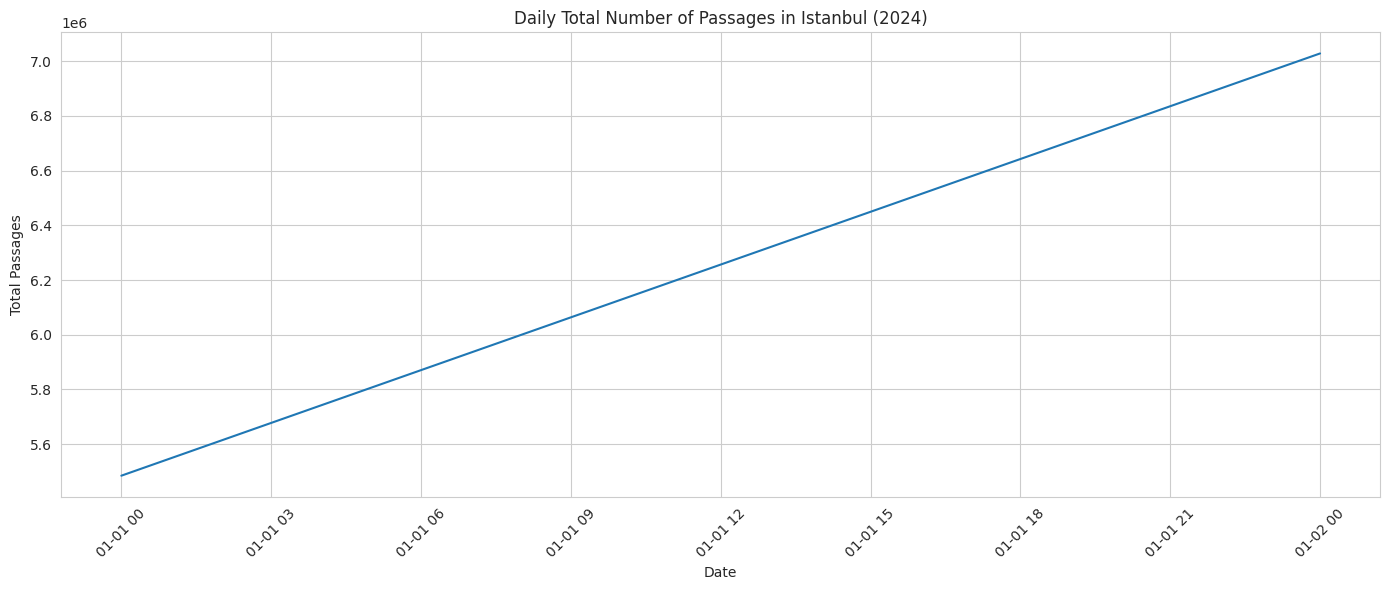

In [23]:
plt.figure(figsize=(14,6))
plt.plot(daily_counts["transition_date"], daily_counts["number_of_passage"])
plt.title("Daily Total Number of Passages in Istanbul (2024)")
plt.xlabel("Date")
plt.ylabel("Total Passages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Total Transport Volume
Aggregating daily data into months reveals major seasonal patterns and monthly variation in city-wide transport demand.

In [22]:
daily_counts["month"] = daily_counts["transition_date"].dt.to_period("M")
monthly_counts = daily_counts.groupby("month")["number_of_passage"].sum().reset_index()
monthly_counts.head()

,month,number_of_passage
0,2024-01,12513360


In [18]:
df_transport.columns

NameError: name 'df_transport' is not defined

## 1. Convert time column to datetime

The transport dataset may contain one or more timestamp-like columns.  
We automatically detect a time column and convert it to proper `datetime`.

In [19]:
time_col = [c for c in df_transport.columns if "time" in c.lower() or "date" in c.lower()][0]
time_col

NameError: name 'df_transport' is not defined

In [22]:
import glob

files = sorted(glob.glob("data/transport/extracted/*.csv"))

with open(files[0], "r") as f_in, open("data/transport/transport_merged.csv", "w") as f_out:
    f_out.write(f_in.readline())

IndexError: list index out of range

In [23]:
import pandas as pd
df = pd.read_csv("data/transport/transport_merged.csv", nrows=5)
df

FileNotFoundError: [Errno 2] No such file or directory: 'data/transport/transport_merged.csv'

In [8]:
os.listdir("data/transport")

['raw', 'transport_merged.csv', 'hourly_transportation_202402.zip']

In [8]:
import os
os.chdir("..")
os.getcwd()

'/workspaces/DSA210-Weather-vs-Transport-Istanbul'

In [9]:
os.listdir("data")

['weather', 'matches', 'transport']

In [4]:
import os
import pandas as pd

input_dir = "data/transport/extracted"

files = sorted([
    os.path.join(input_dir, f)
    for f in os.listdir(input_dir)
    if f.lower().endswith(".csv")
])

print("Found files:", len(files))
files

Found files: 11


['data/transport/extracted/hourly_transportation_202401.csv',
 'data/transport/extracted/hourly_transportation_202402.csv',
 'data/transport/extracted/hourly_transportation_202403.csv',
 'data/transport/extracted/hourly_transportation_202404.csv',
 'data/transport/extracted/hourly_transportation_202405.csv',
 'data/transport/extracted/hourly_transportation_202406.csv',
 'data/transport/extracted/hourly_transportation_202407.csv',
 'data/transport/extracted/hourly_transportation_202408.csv',
 'data/transport/extracted/hourly_transportation_202409.csv',
 'data/transport/extracted/hourly_transportation_202410.csv',
 'data/transport/extracted/hourly_transportation_202411.csv']

In [ ]:
import os

input_dir = "data/transport/extracted"
output_path = "data/transport/transport_merged.csv"

files = sorted([
    os.path.join(input_dir, f)
    for f in os.listdir(input_dir)
    if f.lower().endswith(".csv")
])

print("Found files:", files)

# Eğer eski çıktı varsa sil
if os.path.exists(output_path):
    os.remove(output_path)

header_written = False

with open(output_path, "w", encoding="utf-8") as fout:
    for f in files:
        print("Merging:", f)
        with open(f, "r", encoding="utf-8") as fin:
            header = next(fin)  # ilk satır = header

            if not header_written:
                fout.write(header)
                header_written = True

            for line in fin:
                fout.write(line)

print("DONE →", output_path)

Found files: ['data/transport/extracted/hourly_transportation_202401.csv', 'data/transport/extracted/hourly_transportation_202402.csv', 'data/transport/extracted/hourly_transportation_202403.csv', 'data/transport/extracted/hourly_transportation_202404.csv', 'data/transport/extracted/hourly_transportation_202405.csv', 'data/transport/extracted/hourly_transportation_202406.csv', 'data/transport/extracted/hourly_transportation_202407.csv', 'data/transport/extracted/hourly_transportation_202408.csv', 'data/transport/extracted/hourly_transportation_202409.csv', 'data/transport/extracted/hourly_transportation_202410.csv', 'data/transport/extracted/hourly_transportation_202411.csv']
Merging: data/transport/extracted/hourly_transportation_202401.csv


In [2]:
## -----------------------------------------------------------
## DSA 210 PROJECT: ISTANBUL WEATHER AND TRANSPORT ANALYSIS
## Deliverable: Data Collection, EDA, and Hypothesis Testing
## -----------------------------------------------------------

import pandas as pd
import numpy as np
from scipy import stats
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set global display options and check working directory
pd.set_option('display.max_columns', None)

# Critical: Set working directory to project root for file access robustness
try:
    os.chdir("/workspaces/DSA210-Weather-vs-Transport-Istanbul") 
except FileNotFoundError:
    pass 
print(f"Current Working Directory: {os.getcwd()}")


# --- 1. Data Loading and Optimized Processing ---
# Using chunk-wise reading for the large transportation file to prevent Kernel crash.

# 1.1 Load Transportation Data (Chunk-wise)
cols_to_use = ['transition_date', 'transition_hour', 'number_of_passenger']
chunk_size = 50000 
skip_rows = [1] 

print("Starting Chunked Loading and Daily Aggregation of Transport Data...")

chunk_list = []
for chunk in pd.read_csv(
    "data/transport/transport_merged.csv", 
    usecols=cols_to_use, 
    skiprows=skip_rows,
    low_memory=False, 
    chunksize=chunk_size
):
    chunk['number_of_passenger'] = pd.to_numeric(chunk['number_of_passenger'], errors='coerce').fillna(0)
    chunk['Date'] = pd.to_datetime(
        chunk['transition_date'].astype(str) + ' ' + chunk['transition_hour'].astype(str),
        format='%Y-%m-%d %H', 
        errors='coerce'
    ).dt.normalize()
    
    df_chunk_agg = chunk.groupby('Date')['number_of_passenger'].sum().reset_index()
    chunk_list.append(df_chunk_agg)

df_transport_temp = pd.concat(chunk_list)
df_daily_transport = df_transport_temp.groupby('Date')['number_of_passenger'].sum().reset_index()
df_daily_transport.rename(columns={'number_of_passenger': 'Total_Passengers'}, inplace=True)
print(f"Daily Transport Data Prepared. Total Days: {len(df_daily_transport)}")


# 1.2 Load Auxiliary Data (Weather and Matches)
df_weather = pd.read_csv("data/weatherdata1.csv",skiprows=3)
df_matches = pd.read_csv("data/matches.csv", encoding='latin-1')


# --- 2. Data Preparation and Merging ---

# 2.1 Clean and Normalize Weather Data
df_weather.rename(columns={df_weather.columns[0]: 'Date'}, inplace=True) 
df_weather['Date'] = pd.to_datetime(df_weather['Date']).dt.normalize()

# 2.2 Clean and Normalize Match Data
df_matches.rename(columns={df_matches.columns[0]: 'Match_Event'}, inplace=True)
df_matches['Date'] = pd.to_datetime(df_matches['Match_Event'], errors='coerce').dt.normalize()
df_matches['Match_Day'] = 1 
df_matches_daily = df_matches[['Date', 'Match_Day']].drop_duplicates()

# 2.3 Final Data Merging 
df_merged = df_daily_transport.merge(df_weather, on='Date', how='inner')
df_final = df_merged.merge(df_matches_daily, on='Date', how='left')
df_final['Match_Day'].fillna(0, inplace=True)
df_final['Match_Day'] = df_final['Match_Day'].astype(int)

print("All Datasets Merged and Ready for Analysis.")


# --- 3. Exploratory Data Analysis (EDA) and Hypothesis Testing ---

# 3.1 EDA: Correlation Analysis
correlation_columns = [
    'Total_Passengers', 
    'temperature_2m (°C)', 
    'precipitation (mm)',   
    'Match_Day'             
] 
print("\n--- 3.1 Correlation Matrix (Ridership vs. Environmental Factors) ---")
print(df_final[correlation_columns].corr()) 


# 3.2 Hypothesis Testing: Temperature Effect 
TEMP_THRESHOLD = 20 
hot_days = df_final[df_final['temperature_2m (°C)'] > TEMP_THRESHOLD]['Total_Passengers']
cold_days = df_final[df_final['temperature_2m (°C)'] <= TEMP_THRESHOLD]['Total_Passengers']

if len(hot_days) > 1 and len(cold_days) > 1: 
    t_stat, p_value = stats.ttest_ind(hot_days, cold_days, equal_var=False, nan_policy='omit')

    print("\n--- 3.2 Hypothesis Test Results: Temperature Effect Analysis ---")
    print(f"Hot Days Avg Ridership: {hot_days.mean():,.0f}")
    print(f"Cold Days Avg Ridership: {cold_days.mean():,.0f}")
    print(f"P-Value: {p_value:.4f}")

    if p_value < 0.05:
        print("Conclusion: H0 is rejected. The difference between ridership on hot and cold days is statistically significant.")
    else:
        print("Conclusion: H0 is not rejected.")
else:
    print("Warning: Insufficient data to perform the t-test.")


# --- 4. Data Visualization ---
print("\n--- 4. Data Visualization: Temperature vs. Ridership Scatter Plot ---")

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create Scatter Plot with Regression Line showing the negative correlation
sns.regplot(
    x='temperature_2m (°C)', 
    y='Total_Passengers', 
    data=df_final, 
    scatter_kws={'alpha':0.6}, 
    line_kws={'color':'red'}
)

plt.title('Daily Total Passengers vs. Average Temperature in Istanbul')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Total Daily Public Transport Passengers')
plt.ticklabel_format(style='plain', axis='y') 
plt.show()

Current Working Directory: /workspaces/DSA210-Weather-vs-Transport-Istanbul
Starting Chunked Loading and Daily Aggregation of Transport Data...


EmptyDataError: No columns to parse from file